In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from sklearn.linear_model import LinearRegression

from pathlib import Path

In [13]:
# Load data
CURRENT_DIRECTORY = Path.cwd().resolve()

# Find project root that contains datasets
PROJECT_ROOT = next(
    p for p in [CURRENT_DIRECTORY, *CURRENT_DIRECTORY.parents]
    if (p / "datasets").exists()
)

CLEANED_DATASET_PATH = PROJECT_ROOT / "datasets" / "PAROS_Dataset_Cleaned_2010_2017.csv"

if not CLEANED_DATASET_PATH.exists():
    raise FileNotFoundError(f"Cleaned dataset not found: {CLEANED_DATASET_PATH}")

df = pd.read_csv(CLEANED_DATASET_PATH)
print(f"Loaded cleaned PAROS dataset: {df.shape}")
display(df.head(20))

Loaded cleaned PAROS dataset: (1800, 71)


,Patient brought in by,Date of Incident,Location of incident,Location Unknown,Location Type,Location Type Other,Age,Age Modifier,Gender,Race,...,Reason for discontinuing CPR at ED,Outcome of patient,Patient status,Date of Discharge or Death,Patient neurological status - Cerebral,Patient neurological status - Overall,Patient neurological status - Unknown,EQ5D index,Date Last Saved,Year
0,EMS,2010-06-14,400002.0,NaN,HOME RESIDENCE,NaN,87.0,YEARS,FEMALE,CHINESE,...,DEATH,DIED IN ED,NaN,NaN,NaN,NaN,NaN,NaN,5/23/2013,2010.0
1,EMS,2010-06-16,650210.0,NaN,PUBLIC/COMMERCIAL BUILDING,NaN,75.0,YEARS,MALE,CHINESE,...,DEATH,DIED IN ED,NaN,NaN,NaN,NaN,NaN,NaN,11/9/2012,2010.0
2,EMS,2010-06-19,640815.0,NaN,HOME RESIDENCE,NaN,57.0,YEARS,MALE,MALAY,...,DEATH,DIED IN ED,NaN,NaN,NaN,NaN,NaN,NaN,11/21/2012,2010.0
3,EMS,2010-04-07,644275.0,NaN,HOME RESIDENCE,NaN,54.0,YEARS,MALE,CHINESE,...,DEATH,DIED IN ED,NaN,NaN,NaN,NaN,NaN,NaN,8/26/2011,2010.0
4,EMS,2010-05-07,419319.0,NaN,HOME RESIDENCE,NaN,83.0,YEARS,MALE,CHINESE,...,ROSC,ADMITTED,DIED IN THE HOSPITAL,2010-09-07,NaN,NaN,NaN,NaN,9/14/2011,2010.0
5,EMS,2010-10-07,525450.0,NaN,HOME RESIDENCE,NaN,33.0,YEARS,MALE,MALAY,...,DEATH,DIED IN ED,NaN,NaN,NaN,NaN,NaN,NaN,3/23/2012,2010.0
6,EMS,2010-11-07,567747.0,NaN,HOME RESIDENCE,14 ANG MO KIO CENTRAL 3 GRANDEUR GUARDHOUSE,66.0,YEARS,MALE,CHINESE,...,DEATH,DIED IN ED,NaN,NaN,NaN,NaN,NaN,NaN,8/19/2011,2010.0
7,EMS,2010-07-15,319637.0,NaN,PUBLIC/COMMERCIAL BUILDING,"1 LORONG 2 TOA PAYOH, YELLOW PAGES BUILDING #0...",50.0,YEARS,MALE,CHINESE,...,DEATH,DIED IN ED,NaN,NaN,NaN,NaN,NaN,NaN,8/22/2011,2010.0
8,EMS,2010-07-17,689715.0,NaN,HEALTHCARE FACILITY,"DOCTORS KOO, TEY & ASSOCIATES P.L. YEW TEE MRT",59.0,YEARS,MALE,CHINESE,...,DEATH,DIED IN ED,NaN,NaN,NaN,NaN,NaN,NaN,8/26/2011,2010.0
9,EMS,2010-07-19,270043.0,NaN,HOME RESIDENCE,"COFFEESHOP BLK 43, HOLLAND DRIVE",55.0,YEARS,MALE,CHINESE,...,DEATH,DIED IN ED,NaN,NaN,NaN,NaN,NaN,NaN,8/29/2011,2010.0


In [14]:
# 1. Copy your final filtered dataframe
utstein_df = df.copy()

# 2. Check the exact categories to be completely sure
print("Breakdown of Patient Status:")
print(utstein_df['Patient status'].value_counts(dropna=False))

# 3. Create the binary outcome column
survivor_labels = ['DISCHARGED ALIVE', 'REMAINS IN HOSPITAL AT 30TH DAY POST ARREST']
utstein_df['is_survived'] = (utstein_df['Patient status'].isin(survivor_labels)).astype(int)

# 4. Display the result to verify
display(utstein_df[['Patient brought in by', 'Outcome of patient', 'Patient status', 'is_survived']].head(20))

Breakdown of Patient Status:
Patient status
NaN                                            1185
DIED IN THE HOSPITAL                            297
DISCHARGED ALIVE                                258
REMAINS IN HOSPITAL AT 30TH DAY POST ARREST      60
Name: count, dtype: int64


,Patient brought in by,Outcome of patient,Patient status,is_survived
0,EMS,DIED IN ED,NaN,0
1,EMS,DIED IN ED,NaN,0
2,EMS,DIED IN ED,NaN,0
3,EMS,DIED IN ED,NaN,0
4,EMS,ADMITTED,DIED IN THE HOSPITAL,0
5,EMS,DIED IN ED,NaN,0
6,EMS,DIED IN ED,NaN,0
7,EMS,DIED IN ED,NaN,0
8,EMS,DIED IN ED,NaN,0
9,EMS,DIED IN ED,NaN,0


# 3. Bin the Time to Defibrillation (use Time_to_Defib)

In [15]:
# 1. Convert the time columns to Timedeltas for easy subtraction
t_call = pd.to_timedelta(utstein_df['Time call received at dispatch center'].astype(str), errors='coerce')
t_shock = pd.to_timedelta(utstein_df['Time of first shock given'].astype(str), errors='coerce')

# 2. Calculate the raw difference in minutes
utstein_df['Time_to_Defib_Mins'] = (t_shock - t_call).dt.total_seconds() / 60

# 3. Handle midnight crossovers (e.g., call at 23:55:00 and shock at 00:05:00 results in -1430 mins)
# We add 24 hours (1440 mins) to any negative times
utstein_df.loc[utstein_df['Time_to_Defib_Mins'] < 0, 'Time_to_Defib_Mins'] += 1440

# Optional: View the results to make sure it looks correct
display(utstein_df[['Time call received at dispatch center', 'Time of first shock given', 'Time_to_Defib_Mins']].head(10))

,Time call received at dispatch center,Time of first shock given,Time_to_Defib_Mins
0,11:56:18,NaN,NaN
1,20:45:16,20:58:44,13.466667
2,21:35:02,21:49:30,14.466667
3,15:07:21,15:18:31,11.166667
4,09:38:38,09:53:06,14.466667
5,02:13:57,02:26:03,12.100000
6,17:15:30,17:28:56,13.433333
7,10:34:26,10:43:57,9.516667
8,12:58:35,13:14:03,15.466667
9,22:02:09,22:14:50,12.683333


In [16]:


time_col = 'Time_to_Defib_Mins'

bins = np.arange(0, 22, 2)
midpoints = [1, 3, 5, 7, 9, 11, 13, 15, 17, 19]
# midpoints = [2, 4, 6, 8, 10, 12, 14, 16, 18]


utstein_df['time_bin'] = pd.cut(
    pd.to_numeric(utstein_df[time_col], errors='coerce'),
    bins=bins, labels=midpoints, right=False
)

# 4. Calculate Expected Survival Rate (ESR) per bin

In [17]:
esr_df = utstein_df.groupby('time_bin', observed=False)['is_survived'].mean().reset_index()
esr_df = esr_df.dropna()  # remove any bins with no data

x_vals = esr_df['time_bin'].astype(float)
y_vals = esr_df['is_survived']

# 5. Generate the Paper's Power-Law Curve : y = a * x^b

In [18]:

def power_law(x, a, b):
    return a * (x ** b)

# Fit using curve_fit (log transform could also be used)
popt_power, _ = curve_fit(power_law, x_vals, y_vals, p0=(0.5, -0.5), maxfev=5000)
a_power, b_power = popt_power

# Generate fitted curve
x_power_curve = np.linspace(1, 20, 100)
y_power_curve = power_law(x_power_curve, a_power, b_power)

# R‑squared for power‑law fit
y_pred_power = power_law(x_vals, a_power, b_power)
ss_res_power = np.sum((y_vals - y_pred_power)**2)
ss_tot_power = np.sum((y_vals - np.mean(y_vals))**2)
r2_power = 1 - (ss_res_power / ss_tot_power)

print(f"Power‑law fit: y = {a_power:.4f} * t^{b_power:.4f}, R² = {r2_power:.4f}")

Power‑law fit: y = 0.5614 * t^-0.4717, R² = 0.7944


# 6. Exponential fit: y = a * exp(-b * x)

In [19]:
def exp_decay(x, a, b):
    return a * np.exp(-b * x)

# Fit to binned data (ignore any NaN)
x_fit = x_vals.values
y_fit = y_vals.values

popt, pcov = curve_fit(exp_decay, x_fit, y_fit, p0=(0.5, 0.1), bounds=(0, [1, np.inf]))
a_exp, b_exp = popt

# Generate fitted curve for plotting
x_exp_curve = np.linspace(1, 20, 100)
y_exp_curve = exp_decay(x_exp_curve, a_exp, b_exp)

# R-squared for the exponential fit
residuals = y_fit - exp_decay(x_fit, a_exp, b_exp)
ss_res = np.sum(residuals**2)
ss_tot = np.sum((y_fit - np.mean(y_fit))**2)
r2_exp = 1 - (ss_res / ss_tot)

print(f"Exponential fit: a = {a_exp:.4f}, b = {b_exp:.4f}, R² = {r2_exp:.4f}")

Exponential fit: a = 0.5764, b = 0.1103, R² = 0.9132


# 7. Linear fit: y = intercept + slope * x

In [20]:
X_lin = x_vals.values.reshape(-1, 1)
y_lin = y_vals.values

lin_reg = LinearRegression()
lin_reg.fit(X_lin, y_lin)
intercept_lin = lin_reg.intercept_
slope_lin = lin_reg.coef_[0]

# Generate fitted line
x_lin_curve = np.linspace(1, 20, 100)
y_lin_curve = intercept_lin + slope_lin * x_lin_curve

# R-squared for linear fit
y_pred_lin = lin_reg.predict(X_lin)
ss_res_lin = np.sum((y_lin - y_pred_lin)**2)
ss_tot_lin = np.sum((y_lin - np.mean(y_lin))**2)
r2_lin = 1 - (ss_res_lin / ss_tot_lin)

print(f"Linear fit: survival = {intercept_lin:.4f} + {slope_lin:.4f} * time, R² = {r2_lin:.4f}")

Linear fit: survival = 0.4649 + -0.0232 * time, R² = 0.8328


# 8. Plot

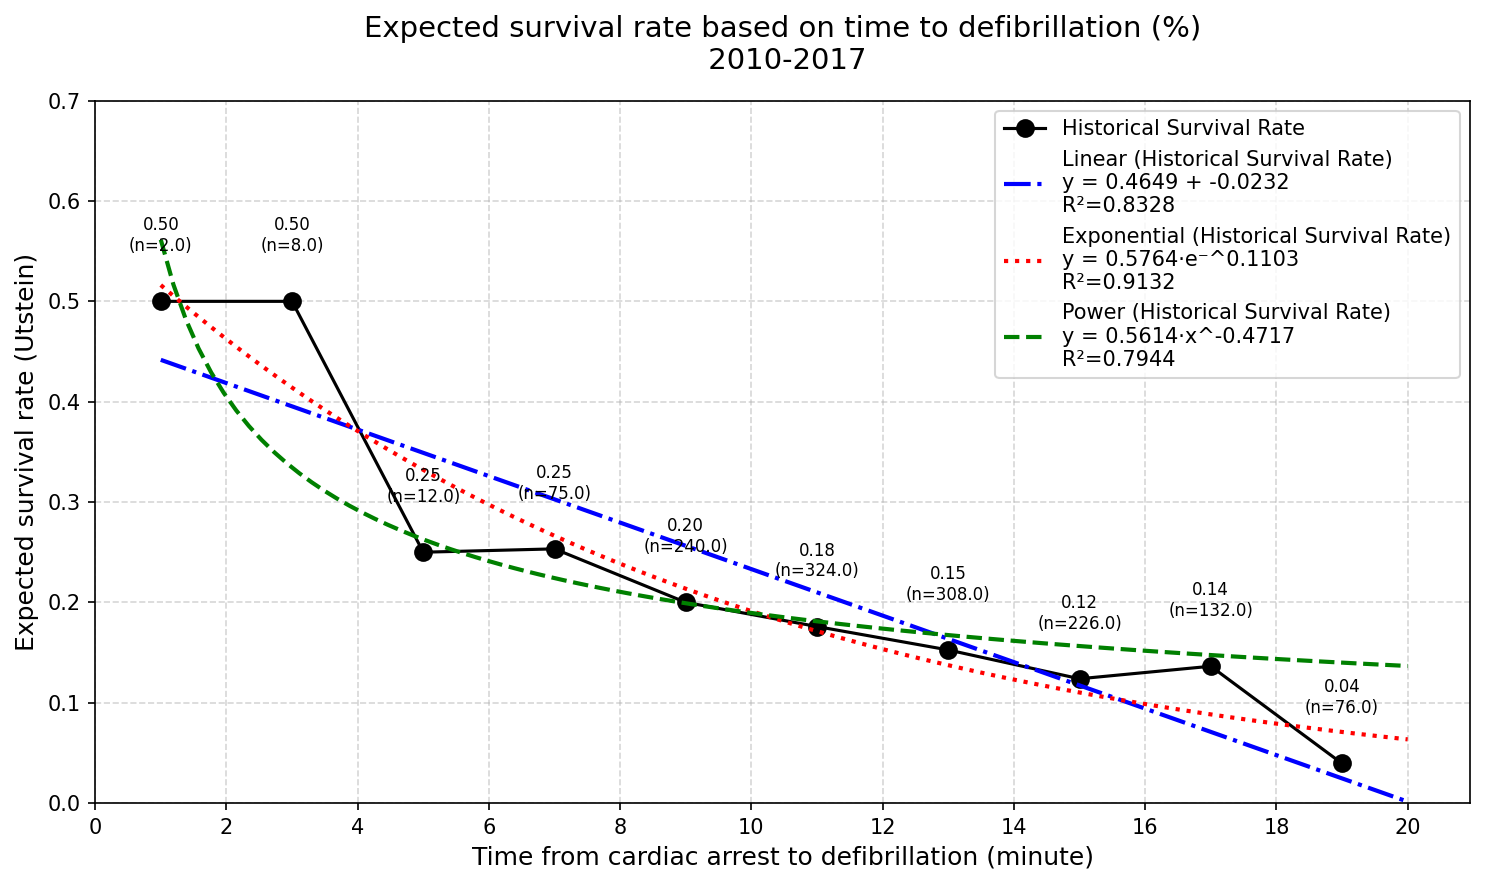

In [21]:
plt.figure(figsize=(10,6), dpi=150)

# Observed data
plt.plot(x_vals, y_vals, marker='o', markersize=8, linestyle='-', color='black', label='Historical Survival Rate')

# Linear fitted line
plt.plot(x_lin_curve, y_lin_curve, linestyle='-.', color='blue', linewidth=2,
         label=f'Linear (Historical Survival Rate)\ny = {intercept_lin:.4f} + {slope_lin:.4f}\nR²={r2_lin:.4f}')
         
# Exponential fitted curve
plt.plot(x_exp_curve, y_exp_curve, linestyle=':', color='red', linewidth=2,
         label=f'Exponential (Historical Survival Rate)\ny = {a_exp:.4f}·e⁻^{b_exp:.4f}\nR²={r2_exp:.4f}')

# Power-law fitted curve
plt.plot(x_power_curve, y_power_curve, linestyle='--', color='green', linewidth=2,
         label=f'Power (Historical Survival Rate)\ny = {a_power:.4f}·x^{b_power:.4f}\nR²={r2_power:.4f}')

# Calculate n per bin
n_per_bin = utstein_df.groupby('time_bin', observed=False)['is_survived'].count().reset_index()
n_per_bin.columns = ['time_bin', 'n']

# Merge with esr_df to get both survival and n
esr_with_n = esr_df.merge(n_per_bin, on='time_bin')

# Annotations
for _, row in esr_with_n.iterrows():
    x = row['time_bin']
    y = row['is_survived']
    n = row['n']
    plt.text(x, y + 0.05, f'{y:.2f}\n(n={n})', ha='center', fontsize=8)

plt.title('Expected survival rate based on time to defibrillation (%)\n 2010-2017', fontsize=14, pad=15)
plt.xlabel('Time from cardiac arrest to defibrillation (minute)', fontsize=12)
plt.ylabel('Expected survival rate (Utstein)', fontsize=12)
plt.xticks(np.arange(0, 22, 2))
plt.ylim(0, 0.70)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig(CURRENT_DIRECTORY / "Utstein_Survival_Curve_2010_2017.png", dpi=300)
plt.show()

In [22]:
# 1. Check your Utstein Sample Size
print(f"Total Utstein Cohort: {len(utstein_df)}")

# 2. Check the distribution of your Time Bins
if 'esr_with_n' in locals():
    print("\nPatient count per 2-minute bin:")
    print(esr_with_n[['time_bin', 'n']])

# 3. Check Etiologies
if 'Cause of arrest' in utstein_df.columns:
    print("\nCause of Arrest breakdown in Utstein cohort:")
    print(utstein_df['Cause of arrest'].value_counts(dropna=False))

# 4. Check Utstein Core Variables (per 2-minute bin)
print("\n--- Utstein Core Variables Breakdown Per Bin ---")

for bin_label in sorted(utstein_df['time_bin'].dropna().unique()):
    bin_df = utstein_df[utstein_df['time_bin'] == bin_label]
    
    print(f"\n=== TIME BIN: {bin_label} (n={len(bin_df)}) ===")
    
    # Witnessed Status (Checking raw 'Arrest witnessed by' column)
    bystander_witnessed = bin_df['Arrest witnessed by'].astype(str).str.contains('BYSTANDER', case=False, na=False).sum()
    not_witnessed = (bin_df['Arrest witnessed by'] == 'NOT WITNESSED').sum()
    ems_witnessed = (bin_df['Arrest witnessed by'] == 'EMS/PRIVATE AMBULANCE').sum()
    unknown_witnessed = len(bin_df) - (bystander_witnessed + not_witnessed + ems_witnessed)

    print("Witnessed Status:")
    print(f"  Bystander Witnessed: {bystander_witnessed}")
    print(f"  Not Witnessed: {not_witnessed}")
    print(f"  EMS Witnessed: {ems_witnessed}")
    print(f"  Unknown/Other: {unknown_witnessed}")

    # First Rhythm (Checking raw 'First arrest rhythm' column)
    shockable = bin_df['First arrest rhythm'].astype(str).str.contains('VF|VT|UNKNOWN SHOCKABLE', case=False, na=False).sum()
    unshockable = len(bin_df) - shockable

    print("First Rhythm:")
    print(f"  Shockable: {shockable}")
    print(f"  Unshockable/Unknown: {unshockable}")

    # Outcome (Using the new 'is_survived' binary column)
    survived = (bin_df['is_survived'] == 1).sum()
    died = (bin_df['is_survived'] == 0).sum()

    print("Outcome Counts:")
    print(f"  Survived/Other: {survived}")
    print(f"  Died/Unknown: {died}")

Total Utstein Cohort: 1800

Patient count per 2-minute bin:
  time_bin    n
0        1    2
1        3    8
2        5   12
3        7   75
4        9  240
5       11  324
6       13  308
7       15  226
8       17  132
9       19   76

Cause of Arrest breakdown in Utstein cohort:
Cause of arrest
NaN    1800
Name: count, dtype: int64

--- Utstein Core Variables Breakdown Per Bin ---

=== TIME BIN: 1 (n=2) ===
Witnessed Status:
  Bystander Witnessed: 2
  Not Witnessed: 0
  EMS Witnessed: 0
  Unknown/Other: 0
First Rhythm:
  Shockable: 2
  Unshockable/Unknown: 0
Outcome Counts:
  Survived/Other: 1
  Died/Unknown: 1

=== TIME BIN: 3 (n=8) ===
Witnessed Status:
  Bystander Witnessed: 8
  Not Witnessed: 0
  EMS Witnessed: 0
  Unknown/Other: 0
First Rhythm:
  Shockable: 8
  Unshockable/Unknown: 0
Outcome Counts:
  Survived/Other: 4
  Died/Unknown: 4

=== TIME BIN: 5 (n=12) ===
Witnessed Status:
  Bystander Witnessed: 12
  Not Witnessed: 0
  EMS Witnessed: 0
  Unknown/Other: 0
First Rhythm:
 